## Load OBO-formatted ontologies (MONDO) into networkx

- Website: [Mondo](https://mondo.monarchinitiative.org/)
- Download: [OBO](http://purl.obolibrary.org/obo/mondo.obo)

<hr style="height:1rem;">

## Imports

In [1]:
import re
import rdflib
import obonet
import pprint

import networkx as nx
from pyvis.network import Network

import matplotlib.pyplot as plt

<hr style="height:1rem;">

## Function Definitions

#### Function to load Ontology OBO file

In [2]:
def load_ontology(obo_file_path):
    """Load the ontology graph using obonet."""
    return obonet.read_obo(obo_file_path)

#### Function to find an OBO ID

In [3]:
def find_obo_id(graph, term):
    """Finds OBO ID(s) for a given term."""
    return [node for node, data in graph.nodes(data=True) if term.lower() in data.get('name', '').lower()]

#### Function to get details about an ID

In [4]:
def get_obo_details(graph, obo_id):
    """Fetch details for a given OBO ID."""
    if obo_id in graph:
        return graph.nodes[obo_id]
    else:
        return {"error": "ID not found"}

#### Function to get xrefs from a MONDO ID

In [5]:
def get_xrefs_from_mondo(mondo_id):
    """Get xrefs for a given MONDO ID from the MONDO OBO graph."""
    data = graph.nodes.get(mondo_id, None)
    if data and 'xref' in data:
        # Extract the xrefs
        xrefs = data['xref']
        # Ensure xrefs is a list (some OBO terms may have a single xref)
        if isinstance(xrefs, str):
            xrefs = [xrefs]
        return xrefs
    else:
        return None  # Return None if no xrefs are found

#### Function to get the MONDO ID from an ICD9 code by searching xrefs

In [6]:
def get_mondo_by_icd9(icd9_code):
    """Find the MONDO ID related to a specific ICD9 code."""
    for node, data in graph.nodes(data=True):
        # Check if xrefs exist for this node
        xrefs = data.get('xref', None)
        if xrefs:
            # Ensure xrefs is a list (some OBO terms may have a single xref)
            if isinstance(xrefs, str):
                xrefs = [xrefs]
            # Search for ICD9 code in xrefs
            for xref in xrefs:
                if f"ICD9:{icd9_code}" in xref:
                    # If found, return the MONDO ID (as this node corresponds to MONDO)
                    return node  # Return the MONDO ID
    return None  # Return None if no MONDO ID is found

#### Function to search for ICD10CM code and get the related MONDO ID

In [7]:
def get_mondo_by_icd10cm(icd10cm_code):
    """Find the MONDO ID related to a specific ICD10CM code."""
    for node, data in graph.nodes(data=True):
        # Check if xrefs exist for this node
        xrefs = data.get('xref', None)
        if xrefs:
            # Ensure xrefs is a list (some OBO terms may have a single xref)
            if isinstance(xrefs, str):
                xrefs = [xrefs]
            # Search for ICD10CM code in xrefs
            for xref in xrefs:
                if f"ICD10CM:{icd10cm_code}" in xref:
                    # If found, return the MONDO ID (as this node corresponds to MONDO)
                    return node  # Return the MONDO ID
    return None  # Return None if no MONDO ID is found

#### Function to search MONDO ID using ICD10CM code with fallback to parent code

In [8]:
def get_mondo_by_icd10cm_or_parent(icd10cm_code):
    while icd10cm_code:
        for node, data in graph.nodes(data=True):
            xrefs = data.get('xref', [])
            if isinstance(xrefs, str):
                xrefs = [xrefs]
            for xref in xrefs:
                if f"ICD10CM:{icd10cm_code}" in xref:
                    return node  # Found MONDO ID

        # If no match, try parent ICD-10 code
        if "." in icd10cm_code:
            icd10cm_code = icd10cm_code.rsplit(".", 1)[0]  # Remove decimal part
        elif len(icd10cm_code) > 3:
            icd10cm_code = icd10cm_code[:-1]  # Remove last character
        else:
            return None  # No parent left to check

    return None  # No MONDO ID found

#### Function to extract related nodes

In [9]:
def extract_subgraph(graph, obo_id, depth=1):
    """Extracts a subgraph of given OBO ID and its relationships up to a certain depth."""
    subgraph_nodes = {obo_id}
    edges = []
    
    for _ in range(depth):
        new_nodes = set()
        for node in list(subgraph_nodes):
            if node in graph:
                # Get parent terms (e.g., "is_a" relationships)
                for parent in graph.predecessors(node):
                    edges.append((parent, node))
                    new_nodes.add(parent)
                # Get child terms
                for child in graph.successors(node):
                    edges.append((node, child))
                    new_nodes.add(child)
        subgraph_nodes.update(new_nodes)
    
    # Create a subgraph
    subgraph = graph.subgraph(subgraph_nodes).copy()
    return subgraph, edges

#### Function to extract related nodes (for Pyvis Network

In [10]:
def extract_pyvis_subgraph(graph, obo_id, depth=2):
    """Extracts a subgraph of given OBO ID and its relationships up to a certain depth."""
    subgraph_nodes = {obo_id}
    edges = []
    
    for _ in range(depth):
        new_nodes = set()
        for node in list(subgraph_nodes):
            if node in graph:
                # Get parent terms (e.g., "is_a" relationships)
                for parent in graph.predecessors(node):
                    edges.append((parent, node, "is_a"))
                    new_nodes.add(parent)
                # Get child terms
                for child in graph.successors(node):
                    edges.append((node, child, "is_a"))
                    new_nodes.add(child)
        subgraph_nodes.update(new_nodes)
    
    return subgraph_nodes, edges

#### Function to extract related nodes for Multiple Subgraphs

In [11]:
def extract_multiple_subgraphs(graph, obo_ids, depth=2):
    """Extracts subgraphs for given OBO IDs and their relationships up to a certain depth."""
    subgraph_nodes = set(obo_ids)
    edges = []
    
    for _ in range(depth):
        new_nodes = set()
        for node in list(subgraph_nodes):
            if node in graph:
                # Get parent terms (e.g., "is_a" relationships)
                for parent in graph.predecessors(node):
                    edges.append((parent, node, "is_a"))
                    new_nodes.add(parent)
                # Get child terms
                for child in graph.successors(node):
                    edges.append((node, child, "is_a"))
                    new_nodes.add(child)
        subgraph_nodes.update(new_nodes)
    
    return subgraph_nodes, edges

#### Function to Extract Unique ICD-10 Codes

In [12]:
def extract_icd10_from_graph(graph):
    """
    Extract unique ICD-10 and ICD-10-CM codes from an OBO graph.

    Args:
    - graph (networkx.MultiDiGraph): The OBO ontology graph.

    Returns:
    - set: Unique ICD-10 and ICD-10-CM codes.
    """
    icd10_codes = set()
    icd10_pattern = re.compile(r"^(ICD10CM|icd10):([\w\.]+)")

    for node, data in graph.nodes(data=True):
        if 'xref' in data:
            for xref in data['xref']:
                match = icd10_pattern.match(xref)
                if match:
                    icd10_codes.add(match.group(2))  # Extract the ICD-10 code

    return icd10_codes

In [13]:
def extract_icd9_from_graph(graph):
    """
    Extract unique ICD-9 and ICD-9-CM codes from an OBO graph.

    Args:
    - graph (networkx.MultiDiGraph): The OBO ontology graph.

    Returns:
    - set: Unique ICD-9 and ICD-9-CM codes.
    """
    icd9_codes = set()
    icd9_pattern = re.compile(r"^(ICD9|icd9):([\w\.]+)")

    for node, data in graph.nodes(data=True):
        if 'xref' in data:
            for xref in data['xref']:
                match = icd9_pattern.match(xref)
                if match:
                    icd9_codes.add(match.group(2))  # Extract the ICD-9 code

    return icd9_codes

In [14]:
def display_obo_hierarchy(graph, start_node='MONDO:0005267', max_depth=10, reverse=False):
    """
    Display the hierarchy of a given OBO graph starting from a specific node.

    Parameters:
    graph (networkx.MultiDiGraph): The OBO graph.
    start_node (str): The node to start displaying the hierarchy from.
    max_depth (int): Maximum depth to avoid recursion overflow.
    reverse (bool): If True, display reverse hierarchy (ancestors).
    """
    def print_hierarchy(node, level=0, visited=None):
        """Recursive function to print hierarchy with depth control."""
        if visited is None:
            visited = set()
        if level > max_depth or node in visited:
            print("  " * level + "... (Max depth reached or already visited)")
            return

        visited.add(node)
        name = graph.nodes[node].get('name', 'Unknown')
        print("  " * level + f"{node} ({name})")

        next_nodes = list(graph.predecessors(node)) if reverse else list(graph.successors(node))
        for next_node in next_nodes:
            if next_node in graph.nodes:
                print_hierarchy(next_node, level + 1, visited)
            else:
                print("  " * (level + 1) + f"{next_node} (Node not found)")

    direction = "Reverse" if reverse else "Forward"
    if start_node in graph:
        print(f"{direction} hierarchy starting from node: {start_node}")
        print_hierarchy(start_node)
    else:
        print(f"Node {start_node} not found in the graph.")

In [15]:
def search_icd_xrefs(graph, icd_codes):
    """
    Search for terms in the ontology with xrefs matching ICD9: or ICD10CM: codes.
    
    Parameters:
        graph (networkx.MultiDiGraph): The ontology graph.
        icd_codes (list of str): List of ICD9 or ICD10CM codes (e.g., ['ICD9:250.00', 'ICD10CM:E11.9']).

    Returns:
        list of dict: List of terms containing all relevant information for matches.
    """
    matched_terms = []

    for node_id, data in graph.nodes(data=True):
        xrefs = data.get("xref", [])
        if isinstance(xrefs, str):
            xrefs = [xrefs]

        for code in icd_codes:
            if any(xref.startswith(code) for xref in xrefs):
                term_info = {
                    "id": node_id,
                    "name": data.get("name"),
                    "definition": data.get("def"),
                    "synonyms": data.get("synonym", []),
                    "xrefs": xrefs,
                    "is_a": data.get("is_a", []),
                }
                matched_terms.append(term_info)
                break  # Skip to the next term once a match is found

    return matched_terms

In [16]:
def search_icd10_plain_codes(graph, plain_icd10_codes):
    """
    Search for ICD-10 codes without the ICD10CM: prefix in xrefs.

    Parameters:
        graph (networkx.MultiDiGraph): The ontology graph.
        plain_icd10_codes (list of str): List of ICD-10 codes without the prefix.

    Returns:
        list of dict: Matched terms with all relevant information.
    """
    matched_terms = []
    target_xrefs = {f"ICD10CM:{code.upper()}" for code in plain_icd10_codes}

    for node_id, data in graph.nodes(data=True):
        xrefs = data.get("xref", [])
        if isinstance(xrefs, str):
            xrefs = [xrefs]

        if any(xref in target_xrefs for xref in xrefs):
            term_info = {
                "id": node_id,
                "name": data.get("name"),
                "definition": data.get("def"),
                "synonyms": data.get("synonym", []),
                "xrefs": xrefs,
                "is_a": data.get("is_a", []),
            }
            matched_terms.append(term_info)

    return matched_terms

In [17]:
def search_icd10_partial_match(graph, icd10_codes):
    """
    Search for ontology terms where ICD10CM xrefs start with any of the provided codes (e.g., B20, F10),
    allowing for matches like ICD10CM:B20.1, ICD10CM:F10.20, etc.

    Parameters:
        graph (networkx.MultiDiGraph): The ontology graph.
        icd10_codes (list of str): ICD-10 codes (without decimals).

    Returns:
        list of dict: Matched terms with relevant information.
    """
    matched_terms = []
    normalized_codes = [code.upper() for code in icd10_codes]

    for node_id, data in graph.nodes(data=True):
        xrefs = data.get("xref", [])
        if isinstance(xrefs, str):
            xrefs = [xrefs]

        for xref in xrefs:
            if xref.startswith("ICD10CM:"):
                for code in normalized_codes:
                    if xref == f"ICD10CM:{code}" or xref.startswith(f"ICD10CM:{code}."):
                        term_info = {
                            "id": node_id,
                            "name": data.get("name"),
                            "definition": data.get("def"),
                            "synonyms": data.get("synonym", []),
                            "xrefs": xrefs,
                            "is_a": data.get("is_a", []),
                        }
                        matched_terms.append(term_info)
                        break  # Stop checking other codes once one matches

    return matched_terms

In [18]:
def search_icd10_partial_match_extended(graph, icd10_codes):
    """
    Search for terms with ICD10CM xrefs that match the given ICD-10 codes (with or without decimals),
    and extract all relevant information.

    Parameters:
        graph (networkx.MultiDiGraph): The ontology graph.
        icd10_codes (list of str): ICD-10 codes without "ICD10CM:" prefix or decimals (e.g., "B53").

    Returns:
        list of dict: List of term information dictionaries.
    """
    matched_terms = []
    normalized_codes = [code.upper() for code in icd10_codes]

    for node_id, data in graph.nodes(data=True):
        xrefs = data.get("xref", [])
        if isinstance(xrefs, str):
            xrefs = [xrefs]

        for xref in xrefs:
            if xref.startswith("ICD10CM:"):
                for code in normalized_codes:
                    if xref == f"ICD10CM:{code}" or xref.startswith(f"ICD10CM:{code}."):
                        term_info = {
                            "id": node_id,
                            "name": data.get("name"),
                            "definition": data.get("def"),
                            "synonyms": data.get("synonym", []),
                            "xrefs": xrefs,
                            "is_a": data.get("is_a", []),
                            "intersection_of": data.get("intersection_of", []),
                            "relationship": data.get("relationship", []),
                            "property_value": data.get("property_value", []),
                            # Optionally include any additional fields present
                            "other_fields": {
                                k: v for k, v in data.items() 
                                if k not in {
                                    "name", "def", "synonym", "xref", "is_a",
                                    "intersection_of", "relationship", "property_value"
                                }
                            }
                        }
                        matched_terms.append(term_info)
                        break  # No need to check more codes once one matches

    return matched_terms

In [19]:
def search_icd10_extended(graph, icd10_codes):
    """
    Search ontology terms whose ICD10CM xrefs match a given list of base ICD-10 codes
    (e.g., B53 matches ICD10CM:B53 and ICD10CM:B53.0).
    
    Extracts all relevant information including:
        - id, name, definition
        - synonyms, xrefs, is_a
        - intersection_of, relationship, property_value

    Parameters:
        graph (networkx.MultiDiGraph): The ontology graph.
        icd10_codes (list of str): ICD-10 codes (without decimals).

    Returns:
        list of dict: A list of matching term metadata dictionaries.
    """
    matched_terms = []
    normalized_codes = [code.upper() for code in icd10_codes]

    for node_id, data in graph.nodes(data=True):
        xrefs = data.get("xref", [])
        if isinstance(xrefs, str):
            xrefs = [xrefs]

        # Check for matching ICD10CM xrefs
        for xref in xrefs:
            if xref.startswith("ICD10CM:"):
                for code in normalized_codes:
                    if xref == f"ICD10CM:{code}" or xref.startswith(f"ICD10CM:{code}."):
                        term_info = {
                            "id": node_id,
                            "name": data.get("name"),
                            "definition": data.get("def"),
                            "synonyms": data.get("synonym", []),
                            "xrefs": xrefs,
                            "is_a": data.get("is_a", []),
                            "intersection_of": data.get("intersection_of", []),
                            "relationship": data.get("relationship", []),
                            "property_value": data.get("property_value", []),
                        }
                        matched_terms.append(term_info)
                        break  # One match is enough
    return matched_terms

<hr style="height:1rem;">

## Read and Load OBO File (mondo.obo)

In [21]:
# Load the OBO file
graph = obonet.read_obo("../data/mondo/mondo.obo")

In [22]:
# Print the terms and their relationships
use_debug = False
if use_debug:
    for node, data in graph.nodes(data=True):
        print(node, data)

##### Number of nodes

In [23]:
len(graph)

53618

##### Number of edges

In [24]:
graph.number_of_edges()

110001

##### Check if the ontology is a DAG

In [25]:
nx.is_directed_acyclic_graph(graph)

False

<hr style="height:1rem;">

## Query the Graph

##### Mapping from term ID to name

In [26]:
id_to_name = {id_: data.get('name') for id_, data in graph.nodes(data=True)}
id_to_name['MONDO:0800439']

'syndromic complex neurodevelopmental disorder'

##### Get xrefs for ```MONDO:0018105```

In [27]:
xrefs = get_xrefs_from_mondo('MONDO:0018105')
print(xrefs)

['DOID:10632', 'GARD:7898', 'icd11.foundation:151381747', 'ICD9:250.80', 'MEDGEN:21923', 'MESH:D014929', 'NANDO:1200757', 'NCIT:C35133', 'Orphanet:3463', 'SCTID:70694009', 'UMLS:C0043207']


##### Get MONDO ID for ICD-9 Code: ```250.80```

In [28]:
icd9_code = "250.80"
mondo_id = get_mondo_by_icd9(icd9_code)
print(mondo_id)

MONDO:0010785


##### Get MONDO ID for ICD-10 Code: ```E70.3```

In [29]:
icd10cm_code = "E70.3"
mondo_id = get_mondo_by_icd10cm(icd10cm_code)
print(mondo_id)

MONDO:0007862


##### Find all superterms of species. Note that networkx.descendants gets superterms, while networkx.ancestors returns subterms.

In [30]:
#nx.descendants(graph, 'MONDO:0800439')

#### Let's look at ```Heart Disease```

In [31]:
term = "Heart Disease"
ids = find_obo_id(graph, term)
print(ids)

['MONDO:0001302', 'MONDO:0001492', 'MONDO:0001493', 'MONDO:0005453', 'MONDO:0006955', 'MONDO:0007461', 'MONDO:0010331', 'MONDO:0010802', 'MONDO:0011817', 'MONDO:0011995', 'MONDO:0012009', 'MONDO:0012010', 'MONDO:0012147', 'MONDO:0012585', 'MONDO:0012628', 'MONDO:0012788', 'MONDO:0013765', 'MONDO:0014239', 'MONDO:0016024', 'MONDO:0016460', 'MONDO:0016515', 'MONDO:0016719', 'MONDO:0017315', 'MONDO:0019153', 'MONDO:0021777', 'MONDO:0022787', 'MONDO:0022831', 'MONDO:0022832', 'MONDO:0022889', 'MONDO:0043529', 'MONDO:0100009', 'MONDO:0100540', 'MONDO:0800441', 'MONDO:1010098', 'MONDO:1010108']


In [32]:
for i in ids:
    details = get_obo_details(graph, i)
    print(i)
    #print(details.keys())
    print("  name: ", details.get('name'))
    print("  def: ", details.get('def'))
    print("  subset: ", details.get('subset'))
    print("  synonym: ", details.get('synonym'))
    print("  xref: ", details.get('xref'))
    print("  is_a: ", details.get('is_a'))
    print("  relationship: ", details.get('relationship'))
    print("  property_value: ", details.get('property_value'))
    print('----------------------------------------------------------')

MONDO:0001302
  name:  hypertensive heart disease
  def:  "Abnormal enlargement of the heart resulting from long-standing hypertension." [NCIT:C4907]
  subset:  ['otar']
  synonym:  ['"hypertensive cardiomegaly" RELATED []', '"hypertensive cardiopathy" RELATED []', '"hypertensive cardiovascular disease" RELATED []', '"hypertensive heart disease" EXACT [DOID:11516, icd11.foundation:1210166201]']
  xref:  ['DOID:11516', 'icd11.foundation:1210166201', 'ICD9:402', 'ICD9:402.9', 'MEDGEN:508889', 'NCIT:C4907', 'SCTID:64715009', 'UMLS:C0152105']
  is_a:  ['MONDO:0005267']
  relationship:  ['disease_arises_from_feature MONDO:0005044']
  property_value:  ['skos:exactMatch DOID:11516', 'skos:exactMatch http://identifiers.org/medgen/508889', 'skos:exactMatch http://identifiers.org/snomedct/64715009', 'skos:exactMatch http://linkedlifedata.com/resource/umls/id/C0152105', 'skos:exactMatch http://purl.obolibrary.org/obo/mondo/sources/icd11foundation/1210166201', 'skos:exactMatch NCIT:C4907']
-------

In [33]:
display_obo_hierarchy(graph, 'MONDO:0001492', reverse=True)

Reverse hierarchy starting from node: MONDO:0001492
MONDO:0001492 (kyphoscoliotic heart disease)


In [34]:
unique_icd10_codes = extract_icd10_from_graph(graph)
print(len(unique_icd10_codes))
#print(unique_icd10_codes)

1166


In [35]:
unique_icd9_codes = extract_icd9_from_graph(graph)
print(len(unique_icd9_codes))
#print(unique_icd9_codes)

3897


<hr style="height:1rem;">

## Graph (DiGraph Network)

### Example: Diabetes

##### Define the term to visualize

In [36]:
obo_id = "HP:0000819"  # "Diabetes mellitus"

##### Extract subgraph

In [37]:
subgraph, edges = extract_subgraph(graph, obo_id, depth=2)

##### Draw the graph

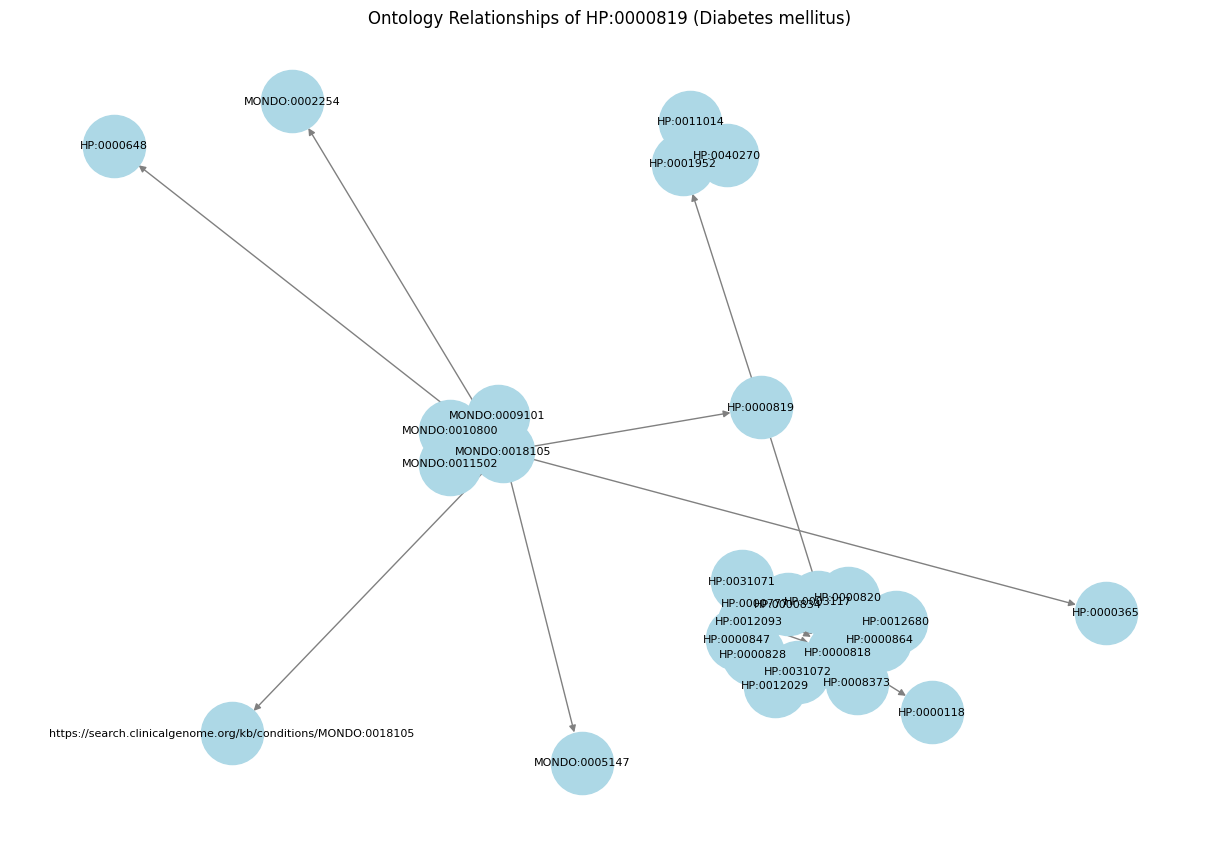

In [38]:
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(subgraph)
nx.draw(subgraph, pos, with_labels=True, node_size=2000, node_color="lightblue", edge_color="gray", font_size=8)
plt.title(f"Ontology Relationships of {obo_id} (Diabetes mellitus)")
plt.show()

<hr style="height:1rem;">

## Graph (Pyvis Network)

### Example: Diabetes

##### Define the term to visualize

In [39]:
obo_id = "HP:0000819"  # "Diabetes mellitus"

##### Extract subgraph

In [40]:
nodes, edges = extract_pyvis_subgraph(graph, obo_id, depth=2)

##### Create Pyvis network

In [41]:
net = Network(notebook=True, height="600px", width="100%", bgcolor="#222222", font_color="white")

##### Add nodes

In [42]:
for node in nodes:
    label = graph.nodes[node].get("name", node)
    color = "red" if node == obo_id else "lightblue"
    net.add_node(node, label=label, title=node, color=color)

##### Add edges

In [43]:
for src, dst, rel in edges:
    net.add_edge(src, dst, title=rel)

##### Save and display

In [46]:
net.show("./plots/mondo_diabetes_ontology_graph.html")

./plots/mondo_diabetes_ontology_graph.html


<hr style="height:1rem;">

## Graph (Pyvis Network) - Multiple Disease

### Example: Diabetes

##### Define the terms to visualize

In [47]:
obo_ids = ["HP:0000819", "HP:0001626"]  # Example: Two diseases - Diabetes and Cardiovascular

##### Extract subgraph for both terms

In [48]:
nodes, edges = extract_multiple_subgraphs(graph, obo_ids, depth=2)

##### Create Pyvis network

In [49]:
net = Network(notebook=True, height="600px", width="100%", bgcolor="#222222", font_color="white")

##### Add nodes

In [50]:
for node in nodes:
    label = graph.nodes[node].get("name", node)
    color = "red" if node in obo_ids else "lightblue"
    net.add_node(node, label=label, title=node, color=color)

##### Add edges

In [51]:
for src, dst, rel in edges:
    net.add_edge(src, dst, title=rel)

##### Save and display

In [52]:
net.show("./plots/mondo_ontology_graph_multiple_diseases.html")

./plots/mondo_ontology_graph_multiple_diseases.html


In [53]:
icd10_codes1 = ['B53', 'F10', 'B20']
icd10_codes2 = [
    "B58", "B06", "A53", "A23", "R20", "R27", "D18", "G51", "R51", "K04",
    "Z88", "F17", "D56", "07TP", "B020", "BW03ZZZ", "G83", "R53", "F10", "A69",
    "B00", "G83", "H04", "B25", "R29", "G83", "G83", "B20", "R47", "B05",
    "K11", "B030", "G60", "B01", "R53", "B99"
]


In [54]:
results = search_icd_xrefs(graph, icd10_codes2)
pprint.pprint(results)
print(f"Number of matching terms: {len(results)}")

[]
Number of matching terms: 0


<hr style="height:0.25rem;">

In [55]:
results = search_icd10_plain_codes(graph, icd10_codes2)

In [56]:
print(f"Number of matching terms: {len(results)}")

Number of matching terms: 8


In [57]:
pprint.pprint(results)

[{'definition': '"An inherited blood disorder characterized by a decreased '
                'synthesis of one of the polypeptide chains that form '
                'hemoglobin. Anemia results from this abnormal hemoglobin '
                'formation." [NCIT:P378]',
  'id': 'MONDO:0000984',
  'is_a': ['MONDO:0019050'],
  'name': 'thalassemia',
  'synonyms': ['"sickle-cell thalassemia with crisis" EXACT [DOID:10241, '
               'ICD9CM:282.42]',
               '"sickle-cell thalassemia without crisis" EXACT [DOID:10241, '
               'ICD9CM:282.41]',
               '"thalassemia Hb-S disease with crisis" EXACT [DOID:10241]',
               '"thalassemia Hb-S disease without crisis" EXACT [DOID:10241]'],
  'xrefs': ['DOID:10241',
            'EFO:1001996',
            'GARD:7756',
            'ICD10CM:D56',
            'ICD9:282.4',
            'ICD9:282.40',
            'ICD9:282.49',
            'MEDGEN:21121',
            'MESH:D013789',
            'NANDO:2200626',
        

<hr style="height:0.25rem;">

In [58]:
results = search_icd10_partial_match(graph, icd10_codes2)

In [59]:
print(f"Number of matching terms: {len(results)}")

Number of matching terms: 37


In [60]:
pprint.pprint(results)

[{'definition': '"A language disorder that involves an acquired impairment of '
                'any language modality such as producing or comprehending '
                'spoken or written language." [DOID:0060046, '
                'http://en.wikipedia.org/wiki/Aphasia]',
  'id': 'MONDO:0000598',
  'is_a': ['MONDO:0004750'],
  'name': 'aphasia',
  'synonyms': [],
  'xrefs': ['DOID:0060046',
            'ICD10CM:R47.01',
            'icd11.foundation:1167055901',
            'MEDGEN:8159',
            'MESH:D001037',
            'UMLS:C0003537']},
 {'definition': '"An inherited blood disorder characterized by a decreased '
                'synthesis of one of the polypeptide chains that form '
                'hemoglobin. Anemia results from this abnormal hemoglobin '
                'formation." [NCIT:P378]',
  'id': 'MONDO:0000984',
  'is_a': ['MONDO:0019050'],
  'name': 'thalassemia',
  'synonyms': ['"sickle-cell thalassemia with crisis" EXACT [DOID:10241, '
               'ICD9CM

<hr style="height:0.25rem;">

In [61]:
results = search_icd10_partial_match_extended(graph, icd10_codes2)

In [62]:
print(f"Number of matching terms: {len(results)}")

Number of matching terms: 37


In [63]:
pprint.pprint(results)

[{'definition': '"A language disorder that involves an acquired impairment of '
                'any language modality such as producing or comprehending '
                'spoken or written language." [DOID:0060046, '
                'http://en.wikipedia.org/wiki/Aphasia]',
  'id': 'MONDO:0000598',
  'intersection_of': [],
  'is_a': ['MONDO:0004750'],
  'name': 'aphasia',
  'other_fields': {},
  'property_value': ['skos:exactMatch DOID:0060046',
                     'skos:exactMatch http://identifiers.org/medgen/8159',
                     'skos:exactMatch http://identifiers.org/mesh/D001037',
                     'skos:exactMatch '
                     'http://linkedlifedata.com/resource/umls/id/C0003537',
                     'skos:exactMatch '
                     'http://purl.bioontology.org/ontology/ICD10CM/R47.01',
                     'skos:exactMatch '
                     'http://purl.obolibrary.org/obo/mondo/sources/icd11foundation/1167055901'],
  'relationship': ['disease_h

<hr style="height:0.25rem;">

In [64]:
results = search_icd10_extended(graph, icd10_codes2)

In [65]:
print(f"Number of matching terms: {len(results)}")

Number of matching terms: 37


In [66]:
pprint.pprint(results)

[{'definition': '"A language disorder that involves an acquired impairment of '
                'any language modality such as producing or comprehending '
                'spoken or written language." [DOID:0060046, '
                'http://en.wikipedia.org/wiki/Aphasia]',
  'id': 'MONDO:0000598',
  'intersection_of': [],
  'is_a': ['MONDO:0004750'],
  'name': 'aphasia',
  'property_value': ['skos:exactMatch DOID:0060046',
                     'skos:exactMatch http://identifiers.org/medgen/8159',
                     'skos:exactMatch http://identifiers.org/mesh/D001037',
                     'skos:exactMatch '
                     'http://linkedlifedata.com/resource/umls/id/C0003537',
                     'skos:exactMatch '
                     'http://purl.bioontology.org/ontology/ICD10CM/R47.01',
                     'skos:exactMatch '
                     'http://purl.obolibrary.org/obo/mondo/sources/icd11foundation/1167055901'],
  'relationship': ['disease_has_feature HP:0002300'